# Using Hadamards and T-gates in Topologiq

In [1]:
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

This notebook offers an example of how to use ***Topologiq*** to perform an algorithmic lattice surgery of a PyZX graph that includes Hadamards and T-gates.

The process requires a PyZX input graph that allows computing Pauli webs.

## PyZX

We will be using a PyZX graph used in a notebook where Alex Kissinger demonstrates usage of Pauli webs in PyZX. It is not too small nor too large to deal with in a notebook, and has the structure needed for compatibility with Topologiq.

The graph is visualised below.

In [2]:
import random
import pyzx as zx
zx.settings.colors = zx.rgb_colors

# Give circuit a legendary name
random.seed(1330)
circuit_name = "Graphy_McGraphy"

# Generate a random CNOT, H, T circuit
c = zx.generate.CNOT_HAD_PHASE_circuit(qubits=3, depth=30)
pyzx_graph = c.to_graph(compress_rows=False)

# Unfuse the non-Clifford spiders, so they look like outputs measured in {|T>, Z|T>}
zx.simplify.gadgetize(pyzx_graph, graphlike=False)
zx.id_simp(pyzx_graph)

# Draw
zx.draw(pyzx_graph, labels=True)

In normal conditions, assuming you know PyZX can calculate Pauli webs for the graph, you would just give the graph above to Topologiq and let it handle Pauli webs automatically.

In this notebook, however, we want to inspect Pauli webs a little before moving forward.

So, the block below prints and visualises the Pauli webs of the PyZX graph above. You will notice by comparing the `order` and the visualisation that:
- T-gate 65 requires information from T-gates 51, 53, 55, meaning it cannot be handled prior in time than its preceding T-gates.
- The path to T-gates 51, 53, 55 includes many but not all spiders in a row prior to them.
- The path to 65 includes all spiders in the path to 51, 53, 55, and a few more.

All spiders (incl. T-gates) in the path to a T-gate must come before the particular T-gate, for all T-gates in circuit. In lattice surgery, this requires ensuring the BlockGraph equivalent objects of the T-gate happen after than all predecessors.

In [3]:
from pyzx.pauliweb import compute_pauli_webs

# Compute Pauli webs
order, zwebs, xwebs = compute_pauli_webs(pyzx_graph)

# Check `order`, which tells the order in which we should measure non-Clifford spiders.
print(order)

# Visualise one of the Pauli webs as example.
zx.draw(pyzx_graph, labels=True, pauli_web=zwebs[65])

{51: 1, 53: 1, 55: 1, 57: 1, 59: 2, 61: 2, 63: 2, 65: 2}


## Topologiq

Let's now go ahead and give the PyZX graph to Topologiq by creating an `AugmentedZXGraph` and giving it to a `BlockGraphManager` to perform the lattice surgery.

Additionally, for any graph including T-gates, we will use the following KWARGs:
- `"graph_traverse_mode": "bfs-layers"`: A tree search rationale (queue) that facilitates management of time orderings involving T-gates by approaching the circuit by layers.
- `"z_stretch": 2` *(or any integer)*: Weight to determine the strenght by which the graph is spread across its time dimension, which also helps to facilitate management of time orderings involving T-gates.

> The ZX graph visualised under the surgery looks a little different from the original ZX graph. Spiders with pi/4 phase are converted into a pattern of phaseless spiders. The specific pattern is discussed [in this slide deck by Austin Fowler](https://docs.google.com/presentation/d/184GHX9jffq9dcwWzbku0K90V9xdA8_25lD8pfeEcgRg/edit?usp=sharing). The pattern is what performs a logical T-gate.

In [9]:
from topologiq.core.graph_manager.graph_manager import BlockGraphManager
from topologiq.input.zx_manager import ZXGraphManager

# KWARGs
# You can opt NOT to include any "kwargs" whatsoever (Topologiq will auto-complete using defaults).
# You can feed specific "kwargs" into the BlockGraphManager to deviate from defaults.
# See `src/topologiq/kwargs.py` for all possible "kwarg" values (write them in lower case if you include manually).
kwargs = {
    "graph_traverse_mode": "tfs",
    "z_stretch": 3,
    "gravity": 7,
}

# ZX graph --> AugmentedZXGraph
zx_graph_manager = ZXGraphManager(debug=1)
aug_zx = zx_graph_manager.add_graph_from_pyzx(pyzx_graph, use_primary=True)

# AugmentedZXGraph --> BlockGraph
bgraph_manager = BlockGraphManager(aug_zx, **kwargs)
bgraph_manager.build()


=> Ingesting PyZX graph.
* Consuming raw input graph.
* Storing a reduced version of graph.
* Calculating Pauli webs using PyZX.

=> Building BlockGraph.

=> SUCCESS! Habemus BlockGraph. 
  - Volume: 347. 
  - Duration: 2.77s.



We can, of course, visualise results.

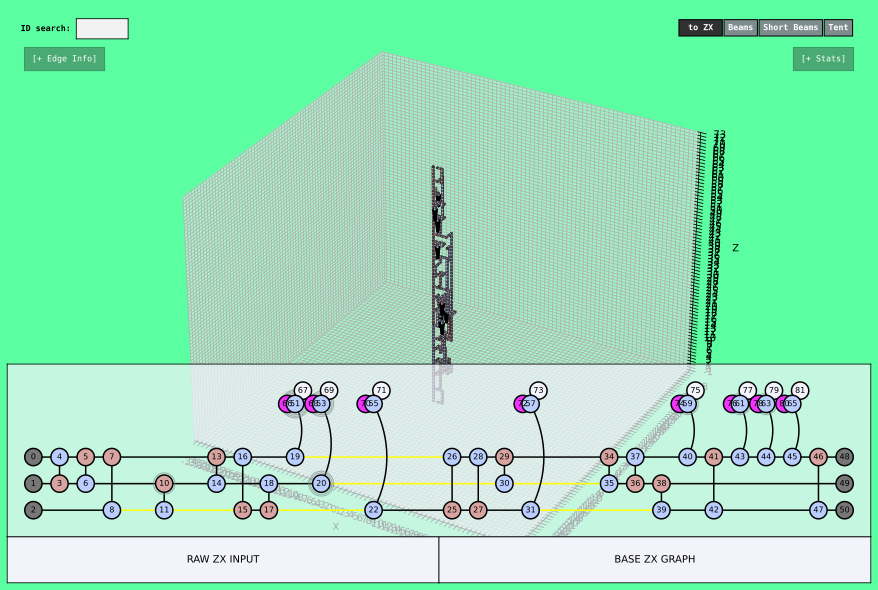

In [10]:
# Visualise results
bgraph_manager.draw_blockgraph()

And we can also confirm that all predecessors of a given T-gate do indeed happen before the specific T-gate.

For this, we can request the `bgraph_manager`'s `ante` attribute, a dictionary of all cubes with predecessors and their predecessors.
- Keys corresponds to the conditional cube in a given T-gate pattern, the specific cube in the pattern that must happen after predecessors.
- Values are lists with the IDs of all cubes that must come before the key.
- The coords of all cubes can be queried from the `bgraph_manager`'s `bgraph`, which holds the primary NX graph used during build.

In [11]:
# Print all cubes that must come before other cubes
time_oops = False
for k, v in bgraph_manager.ante.items():
    coords_of_conditional_cube = bgraph_manager.bgraph.nodes[k]["coords"]
    for cube_id in v:
        cube_coords = bgraph_manager.bgraph.nodes[cube_id]["coords"]
        if cube_coords[2] >= coords_of_conditional_cube[2]:
            time_oops = True
            print(f"Cube with ID {cube_id} happens AFTER conditional cube with ID {k}, which violates time constraints needed for successful computation.")

if not time_oops:
    print("#EPIC. No time-ordering violations detected.")

#EPIC. No time-ordering violations detected.


## Output

That's it! That's all it takes. 

To write result to file, just use the `bgraph_manager`'s `write_bgraph` method.

In [12]:
output_dir = os.path.join(repo_root, "output/bgraph")
bgraph_manager.write_bgraph(circuit_name=circuit_name)